<a href="https://colab.research.google.com/github/IbHansen/mfdemo/blob/main/pakistan/PAK_CarbonTax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib Notebook

In [ ]:
#This is code to manage dependencies if the notebook is executed in the google colab cloud service
# Only run installs on Colab
import importlib.util

if 'google.colab' in str(get_ipython()):
    if importlib.util.find_spec("modelclass") is None:
        !apt-get -qq install -y graphviz
        !pip -qq install ModelFlowIb
        !mkdir -p data && curl -L https://raw.githubusercontent.com/worldbank/MFMod-ModelFlow/main/models/Pakistan/data/pak_new.pcim -o data/pak_new.pcim
        from google.colab import output
        output.enable_custom_widget_manager()    


In [3]:
from modelclass import model

## Run Pakistan baseline

In [4]:
mpak,bline = model.modelload('data/pak_new.pcim', alfa=0.7,run=1,keep= 'Baseline')


Zipped file read:  data\pak_new.pcim


## Simulating the impact of imposing a carbon price

To run a simulation, the following steps must invariably be followed.
1. Create a new DataFrame, typically a copy of an existing one.
2. Change the value in the new df of the variable(s) to be shocked.
3. Solve the model using the newly altered df as the input df.

In [5]:

# Set a new CT30df to create carbon tax series
CT30df = bline.upd("<2025 2100> PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER = 30")

#solve the scenario with 30 USD carbon price
resultsdf = mpak(CT30df,2020,2100,keep="Nominal $30USD Carbon tax") # simulates the model


In [6]:
with mpak.set_smpl(2023,2030):
    print(mpak['PAKCCEMISCO2*'].difpctlevel.rename().df);


      PAKCCEMISCO2CKN  PAKCCEMISCO2GKN  PAKCCEMISCO2OKN  PAKCCEMISCO2TKN
2023     2.790218e-08     1.414445e-08     2.759975e-08     2.411261e-08
2024     3.219165e-08     1.527997e-08     3.182027e-08     2.759326e-08
2025    -4.118618e+01    -2.699293e+01    -1.092982e+01    -2.216710e+01
2026    -4.005639e+01    -2.571519e+01    -1.098118e+01    -2.156470e+01
2027    -3.885182e+01    -2.447687e+01    -1.088815e+01    -2.089059e+01
2028    -3.758830e+01    -2.329774e+01    -1.068014e+01    -2.016578e+01
2029    -3.626124e+01    -2.214429e+01    -1.035476e+01    -1.937752e+01
2030    -3.489288e+01    -2.100862e+01    -9.946512e+00    -1.854539e+01


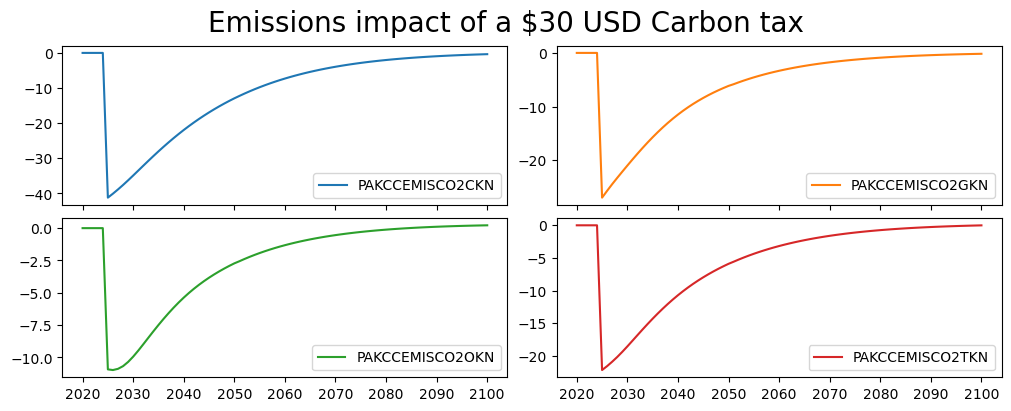

In [7]:
mpak['PAKCCEMISCO2?KN'].difpctlevel.rename().plot(title="Emissions impact of a $30 USD Carbon tax");


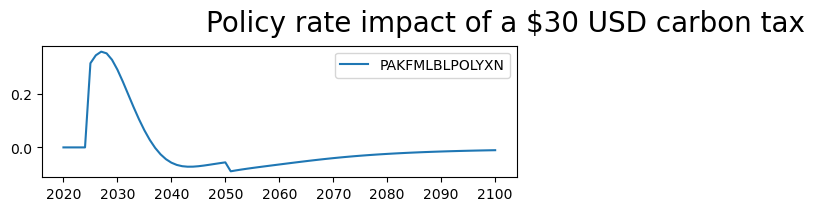

In [8]:
mpak['PAKFMLBLPOLYXN'].dif.plot(title="Policy rate impact of a $30 USD carbon tax");

